In [4]:
!pip install tensorflow opencv-python matplotlib scikit-learn

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, AveragePooling2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

ModuleNotFoundError: No module named 'matplotlib'

In [27]:
!unzip face-mask-detection.zip -d /content/face-mask-detection

Archive:  face-mask-detection.zip
replace /content/face-mask-detection/annotations/maksssksksss0.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/face-mask-detection/annotations/maksssksksss0.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss1.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss10.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss100.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss101.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss102.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss103.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss104.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss105.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss106.xml  
  inflating: /content/face-mask-detection/annotations/maksssksksss107.xml  
  inflating: /content/face-

In [28]:
BASE_DIR = "/content/face-mask-detection"
IMG_SIZE = 224
CATEGORIES = ["with_mask", "without_mask"]

In [29]:
image_paths = []
labels = []

for category in CATEGORIES:
    cat_path = os.path.join(BASE_DIR, category)
    if os.path.exists(cat_path):
        for img_name in os.listdir(cat_path):
            img_path = os.path.join(cat_path, img_name)
            if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                image_paths.append(img_path)
                labels.append(category)

len(image_paths), len(labels)

Total original images found: 853
Total faces extracted for training: 3949
Shape of training data (faces): (3949, 224, 224, 3)
Shape of training labels: (3949,)


In [29]:
data = []
valid_labels = []

for path, label in zip(image_paths, labels):
    image = cv2.imread(path)
    if image is None:
        continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image.astype("float32") / 255.0
    data.append(image)
    valid_labels.append(label)

data = np.array(data)
labels = np.array(valid_labels)

data.shape, labels.shape

In [30]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = np.concatenate([labels, 1 - labels], axis=1)
labels[:5], lb.classes_

(array([[1, 0],
        [1, 0],
        [1, 0],
        [1, 0],
        [1, 0]]),
 array(['with_mask', 'without_mask'], dtype='<U12'))

In [31]:
trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.2, stratify=labels, random_state=42
)

In [32]:
aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [33]:
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

/tmp/ipykernel_9694/2131297001.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [34]:
INIT_LR = 1e-4
EPOCHS = 10
BS = 32

opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

In [35]:
H = model.fit(
    aug.flow(trainX, trainY, batch_size=BS),
    steps_per_epoch=len(trainX) // BS,
    validation_data=(testX, testY),
    validation_steps=len(testX) // BS,
    epochs=EPOCHS
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8008 - loss: 0.4995 - val_accuracy: 0.8190 - val_loss: 0.3866
Epoch 2/10
 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:14 771ms/step - accuracy: 0.7812 - loss: 0.5380

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 0.7812 - loss: 0.5380 - val_accuracy: 0.8190 - val_loss: 0.3858
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8318 - loss: 0.3963 - val_accuracy: 0.8519 - val_loss: 0.3290
Epoch 4/10
 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:09 712ms/step - accuracy: 0.8750 - loss: 0.3410

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 0.8750 - loss: 0.3410 - val_accuracy: 0.8519 - val_loss: 0.3285
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8491 - loss: 0.3585 - val_accuracy: 0.8835 - val_loss: 0.3018
Epoch 6/10
 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:13 753ms/step - accuracy: 0.8438 - loss: 0.3677

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.8438 - loss: 0.3677 - val_accuracy: 0.8861 - val_loss: 0.3007
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8535 - loss: 0.3312 - val_accuracy: 0.8911 - val_loss: 0.2754
Epoch 8/10
 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:14 772ms/step - accuracy: 0.8750 - loss: 0.2919

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.8750 - loss: 0.2919 - val_accuracy: 0.8911 - val_loss: 0.2752
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8654 - loss: 0.3074 - val_accuracy: 0.8949 - val_loss: 0.2588
Epoch 10/10
 1/98 ━━━━━━━━━━━━━━━━━━━━ 1:13 758ms/step - accuracy: 0.8438 - loss: 0.2920

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.8438 - loss: 0.2920 - val_accuracy: 0.8949 - val_loss: 0.2588


In [36]:
model.save("/content/mask_detector.h5")

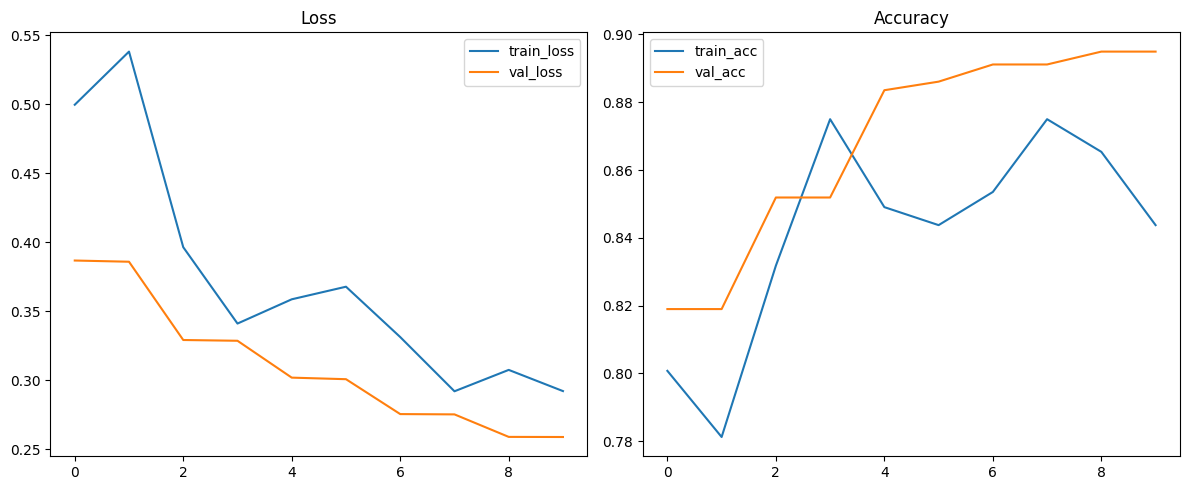

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(H.history["loss"], label="train_loss")
plt.plot(H.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(H.history["accuracy"], label="train_acc")
plt.plot(H.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

In [38]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224)) / 255.0
    pred = model.predict(np.expand_dims(img_resized, axis=0), verbose=0)[0]
    label = "with_mask" if pred[0] > pred[1] else "without_mask"

    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()

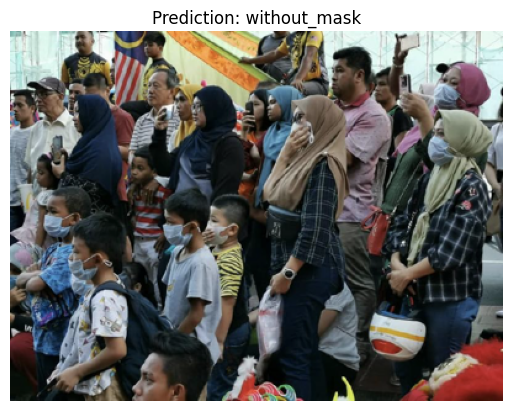

In [39]:
predict_image(image_paths[0])

In [40]:
!mkdir -p /content/face_detector

!wget -q -O /content/face_detector/deploy.prototxt \
https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt

!wget -q -O /content/face_detector/res10_300x300_ssd_iter_140000.caffemodel \
https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel

In [41]:
prototxt = "/content/face_detector/deploy.prototxt"
weights = "/content/face_detector/res10_300x300_ssd_iter_140000.caffemodel"
faceNet = cv2.dnn.readNet(prototxt, weights)
maskNet = load_model("/content/mask_detector.h5")

In [42]:
def detect_and_predict_mask(frame, faceNet, maskNet):
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
    faceNet.setInput(blob)
    detections = faceNet.forward()

    locs = []
    preds = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            startX, startY, endX, endY = box.astype("int")

            startX = max(0, startX)
            startY = max(0, startY)
            endX = min(w - 1, endX)
            endY = min(h - 1, endY)

            face = frame[startY:endY, startX:endX]
            if face.size == 0:
                continue

            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face = cv2.resize(face, (224, 224))
            face = face.astype("float32") / 255.0
            face = np.expand_dims(face, axis=0)

            locs.append((startX, startY, endX, endY))
            preds.append(maskNet.predict(face, verbose=0)[0])

    return locs, preds

In [43]:
vs = cv2.VideoCapture(0)

while True:
    ret, frame = vs.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    (locs, preds) = detect_and_predict_mask(frame, faceNet, model)

    for (box, pred) in zip(locs, preds):
        (startX, startY, endX, endY) = box
        (mask, withoutMask) = pred

        label = "Mask" if mask > withoutMask else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)

        cv2.putText(frame, label, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        cv2.rectangle(frame, (startX, startY), (endX, endY), color, 2)

    cv2.imshow("Face Mask Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

vs.release()
cv2.destroyAllWindows()